# Miniproyecto: Clasificación de Sentimientos de Reseñas de Películas en IMDb con Redes Neuronales Recurrentes

**Curso:** Técnicas de Deep Learning  

**Dataset:** BIMDB Movie Ratings Sentiment Analysis (Kaggle) — 40k reseñas, 2 clases

**Framework:** PyTorch

**Grupo:** 24

**Integrantes:** Jaime Rodriguez, Juan Martin Santos, Yezid Garcia

## Descripción del problema

El problema consiste en clasificar automáticamente reseñas de películas del dataset IMDb como positivas o negativas, utilizando Redes Neuronales Recurrentes (LSTM o GRU) que, gracias a su capacidad de capturar dependencias contextuales en secuencias de texto, permiten identificar patrones de sentimiento con mayor precisión que métodos tradicionales.


## Tabla de contenido

1. [Importación de Librerías y Configuración](#1)
2. [Carga de los datos](#2)
3. [Pipeline de limpieza y tokenizacion](#3)
4. [Vocabulario e indexado](#4)
5. [Arquitectura de la RNN](#5)
6. [Entrenamiento de la red LSTM](#6)
7. [Resultado cuantitativo](#7)
8. [Análisis cualitativo](#8)

## 1. Importación de Librerías y Configuración

Se fijan semillas aleatorias en PyTorch y NumPy para garantizar **reproducibilidad**: cualquier ejecución del notebook producirá exactamente los mismos splits, inicializaciones de pesos y orden de batches.

Finalmente se descargan las bases de datos de NLTK para el preprocesamiento de las reseñas.

In [17]:
# Importaciones
import pandas as pd
import numpy as np
import re
import json
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import gensim.downloader as api
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

SEMILLA: int = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

PAPER_DIR: Path = Path('/home/jaime/Projects/maia/local/tdl/miniproyecto2/paper_template')

[nltk_data] Downloading package stopwords to /home/jaime/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jaime/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jaime/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Carga de los datos

En esta sección se cargan las 40k reseñas desde un archivos csv, se chequea el balanceo de las categorias y se identifican entradas potencialmente imputables.

Como resultado tenemos un dataset balanceado y sin entradas vacias.

In [18]:
# Cargar datos
df = pd.read_csv('/home/jaime/Projects/maia/local/tdl/miniproyecto2/movie.csv')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()

Filas: 40000, Columnas: 2


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


label
0    20019
1    19981
Name: count, dtype: int64


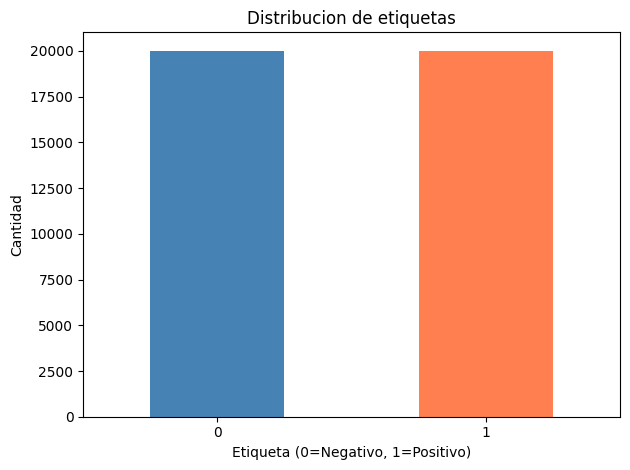

In [20]:
# Distribucion de etiquetas
distribucion: pd.Series = df['label'].value_counts().sort_index()
print(distribucion)
distribucion.plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribucion de etiquetas')
plt.xlabel('Etiqueta (0=Negativo, 1=Positivo)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PAPER_DIR / 'distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Verificar filas imputables (nulos o texto vacio)
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nFilas con texto vacio: {(df["text"].str.strip() == "").sum()}')

df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.strip() != '']
df = df.reset_index(drop=True)
print(f'\nFilas tras limpieza: {len(df)}')

Valores nulos por columna:
text     0
label    0
dtype: int64

Filas con texto vacio: 0

Filas tras limpieza: 40000


## 3. Pipeline de limpieza y tokenizacion

Cada resena pasa por los siguientes pasos:

1. **Eliminar HTML** -- etiquetas `<br />`, `<b>`, etc.
2. **Filtrar caracteres** -- solo letras A-Z; numeros y puntuacion se descartan.
3. **Minusculas** -- normalizacion de mayusculas.
4. **Stopwords** -- eliminacion de palabras sin carga semantica (ingles).
5. **Lematizacion** -- `WordNetLemmatizer` reduce cada token a su forma base.

### Ejemplo entrada vs salida

**Entrada (texto crudo):**
```
"A waste of film. Utter rubbish.<br /><br />Frakes should hand in his directors chair!"
```

**Salida (lista de tokens):**
```python
['waste', 'film', 'utter', 'rubbish', 'frake', 'hand', 'director', 'chair']
```

Los tokens se mapean a indices usando el vocabulario construido desde el conjunto de entrenamiento.
Las palabras presentes en GloVe se inicializan con sus vectores, las demas se inicializan en cero.


**Split del dataset:**
El dataset se divide en tres conjuntos estratificados para preservar el balance de clases: **80 % entrenamiento** (32 000 reseñas), **10 % validación** (4 000) y **10 % prueba** (4 000). La semilla fija garantiza que la partición sea reproducible.

In [22]:
# Pipeline: limpieza, tokenizacion, stopwords, lematizacion
palabras_stop: set[str] = set(stopwords.words('english'))
lematizador: WordNetLemmatizer = WordNetLemmatizer()


def limpiar_texto(texto: str) -> list[str]:
    # type: (str) -> list[str]
    """Limpia y tokeniza: elimina HTML, filtra no-letras, quita stopwords y lematiza."""
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = re.sub(r'[^a-zA-Z]', ' ', texto)
    texto = texto.lower()
    tokens: list[str] = texto.split()
    tokens = [lematizador.lemmatize(t) for t in tokens
              if t not in palabras_stop and len(t) > 1]
    return tokens


print('Procesando textos...')
df['tokens'] = df['text'].apply(limpiar_texto)

# Cargar vectores GloVe preentrenados (primera ejecucion descarga ~65 MB)
print('Cargando GloVe...')
glove: KeyedVectors = api.load('glove-wiki-gigaword-100')
VECTOR_SIZE: int = 100
print(f'GloVe cargado: {len(glove.key_to_index)} palabras, dimension {VECTOR_SIZE}')
print('Ejemplo entrada:', df['text'][0][:80], '...')
print('Ejemplo salida: ', df['tokens'][0][:10])

Procesando textos...
Cargando GloVe...
GloVe cargado: 400000 palabras, dimension 100
Ejemplo entrada: I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school ...
Ejemplo salida:  ['grew', 'watching', 'loving', 'thunderbird', 'mate', 'school', 'watched', 'played', 'thunderbird', 'school']


In [23]:
# Dividir en entrenamiento (80%), validacion (10%) y prueba (10%)
X: np.ndarray = df['tokens'].values
y: np.ndarray = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEMILLA, stratify=y_temp
)
print(f'Entrenamiento: {len(X_train)}')
print(f'Validacion:    {len(X_val)}')
print(f'Prueba:        {len(X_test)}')

Entrenamiento: 32000
Validacion:    4000
Prueba:        4000


## 4. Vocabulario e indexado

El vocabulario se construye **exclusivamente desde el conjunto de entrenamiento** para evitar fuga de datos. Cada palabra recibe un índice entero; se reservan dos especiales: `0` (padding) y `1` (token desconocido). La matriz de embeddings se inicializa con vectores GloVe cuando la palabra está en el vocabulario preentrenado (cobertura 77 %), y con ceros en caso contrario.

In [24]:
# Vocabulario e indices basados en el conjunto de entrenamiento
MAX_LEN: int = 300
PAD_IDX: int = 0
UNK_IDX: int = 1

contador: Counter = Counter(t for tokens in X_train for t in tokens)
vocab: list[str] = [w for w, _ in contador.most_common()]
word2idx: dict[str, int] = {w: i + 2 for i, w in enumerate(vocab)}
VOCAB_SIZE: int = len(word2idx) + 2

# Matriz de embeddings inicializada con GloVe
embedding_matrix: np.ndarray = np.zeros((VOCAB_SIZE, VECTOR_SIZE))
cobertura: int = 0
for word, idx in word2idx.items():
    if word in glove.key_to_index:
        embedding_matrix[idx] = glove[word]
        cobertura += 1
print(f'Vocabulario: {VOCAB_SIZE} palabras')
print(f'Cobertura GloVe: {cobertura}/{len(word2idx)} ({100*cobertura/len(word2idx):.1f}%)')


def tokens_a_indices(tokens: list[str], max_len: int = MAX_LEN) -> list[int]:
    # type: (list[str], int) -> list[int]
    """Convierte tokens a indices enteros con padding hasta max_len."""
    indices: list[int] = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices

Vocabulario: 74495 palabras
Cobertura GloVe: 57522/74493 (77.2%)


## 5. Arquitectura de la RNN

El sistema se construye extendiendo las clases base de PyTorch mediante herencia: **`ComentariosDataset`** hereda de `torch.utils.data.Dataset` e implementa `__len__` y `__getitem__` para integrar el pipeline de tokenización con los `DataLoader`; **`SentimentBiLSTM`** hereda de `nn.Module` y define el grafo de cómputo en `forward`.

La red encadena cuatro etapas:

| Capa | Detalle |
|---|---|
| `Embedding` | 74 495 × 100, inicializado con GloVe, congelado las primeras 3 épocas |
| `BiLSTM` | 1 capa, hidden = 128, bidireccional → salida de 256 dimensiones |
| Mean pooling | Promedio de los estados ocultos de toda la secuencia |
| `Linear` + `Sigmoid` | Proyección a un escalar ∈ (0, 1) para clasificación binaria |

La clase auxiliar **`EarlyStopping`** monitorea la pérdida de validación y detiene el entrenamiento si no hay mejora mayor a `1e-4` durante 5 épocas consecutivas, evitando sobreajuste sin necesidad de fijar un número fijo de épocas.


In [25]:
# Dataset y DataLoaders
class ComentariosDataset(Dataset):
    """Dataset de resenas con etiquetas de sentimiento."""

    def __init__(self, textos: np.ndarray, etiquetas: np.ndarray) -> None:
        # type: (np.ndarray, np.ndarray) -> None
        """Convierte tokens a tensores de indices y almacena etiquetas."""
        self.X: list[torch.Tensor] = [
            torch.tensor(tokens_a_indices(t), dtype=torch.long) for t in textos
        ]
        self.y: torch.Tensor = torch.tensor(etiquetas, dtype=torch.float32)

    def __len__(self) -> int:
        # type: () -> int
        # Numero de muestras
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        # type: (int) -> tuple[torch.Tensor, torch.Tensor]
        # Devuelve par (secuencia de indices, etiqueta)
        return self.X[idx], self.y[idx]


BATCH_SIZE: int = 128
train_ds: ComentariosDataset = ComentariosDataset(X_train, y_train)
val_ds:   ComentariosDataset = ComentariosDataset(X_val,   y_val)
test_ds:  ComentariosDataset = ComentariosDataset(X_test,  y_test)

train_loader: DataLoader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4
)
val_loader: DataLoader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, num_workers=4
)
test_loader: DataLoader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, num_workers=4
)
print(f'Batches de entrenamiento: {len(train_loader)}')

Batches de entrenamiento: 250


In [26]:
# Modelo BiLSTM y clase de parada anticipada

class SentimentBiLSTM(nn.Module):
    """BiLSTM con mean pooling para clasificacion binaria de sentimiento."""

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        n_layers: int,
        dropout: float = 0.3,
    ) -> None:
        # type: (int, int, int, int, float) -> None
        """Inicializa capas: embedding, BiLSTM y densa de salida."""
        super().__init__()
        # Embedding inicializado con GloVe; se congela al inicio del entrenamiento
        self.embedding: nn.Embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=PAD_IDX
        )
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        # Capa BiLSTM bidireccional
        self.lstm: nn.LSTM = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.dropout_layer: nn.Dropout = nn.Dropout(dropout)
        # FC de salida; hidden_dim * 2 por bidireccionalidad
        self.fc: nn.Linear = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid: nn.Sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # type: (torch.Tensor) -> torch.Tensor
        """Embedding, BiLSTM con mean pooling sobre estados ocultos, FC y sigmoid."""
        emb: torch.Tensor = self.dropout_layer(self.embedding(x))
        output, _ = self.lstm(emb)
        # Promedio de los estados ocultos de todas las posiciones de la secuencia
        pooled: torch.Tensor = output.mean(dim=1)
        salida: torch.Tensor = self.fc(self.dropout_layer(pooled))
        return self.sigmoid(salida).squeeze(1)


class EarlyStopping:
    """Detiene el entrenamiento cuando val_loss no mejora durante patience epocas."""

    def __init__(self, patience: int = 5, min_delta: float = 1e-4) -> None:
        # type: (int, float) -> None
        """Inicializa contador y umbral minimo de mejora."""
        self.patience: int = patience
        self.min_delta: float = min_delta
        self.counter: int = 0
        self.best_loss: float = float('inf')
        self.stop: bool = False

    def step(self, val_loss: float) -> None:
        # type: (float) -> None
        """Actualiza estado; activa self.stop si no hay mejora en patience epocas."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


HIDDEN_DIM: int = 128
N_LAYERS: int = 1
device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

modelo: SentimentBiLSTM = SentimentBiLSTM(
    VOCAB_SIZE, VECTOR_SIZE, HIDDEN_DIM, N_LAYERS
).to(device)
print(modelo)
total_params: int = sum(p.numel() for p in modelo.parameters())
print(f'Parametros totales: {total_params:,}')

Dispositivo: cpu
SentimentBiLSTM(
  (embedding): Embedding(74495, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Parametros totales: 7,685,277


/home/jaime/Projects/maia/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [27]:
# Vista de la arquitectura del modelo usando funciones estandar de PyTorch

def mostrar_arquitectura(model: nn.Module) -> None:
    # type: (nn.Module) -> None
    """Imprime capas, formas de parametros y total entrenable."""
    print('=' * 60)
    print(f'Arquitectura: {model.__class__.__name__}')
    print('=' * 60)
    print(model)
    print()
    print(f'{'Capa':<35} {'Forma':>20} {'Entrenable':>12}')
    print('-' * 70)
    total: int = 0
    entrenables: int = 0
    for name, param in model.named_parameters():
        n: int = param.numel()
        total += n
        if param.requires_grad:
            entrenables += n
        print(f'{name:<35} {str(list(param.shape)):>20} {str(param.requires_grad):>12}')
    print('-' * 70)
    print(f'Total parametros:        {total:>12,}')
    print(f'Parametros entrenables:  {entrenables:>12,}')
    print('=' * 60)


mostrar_arquitectura(modelo)

Arquitectura: SentimentBiLSTM
SentimentBiLSTM(
  (embedding): Embedding(74495, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Capa                                               Forma   Entrenable
----------------------------------------------------------------------
embedding.weight                            [74495, 100]         True
lstm.weight_ih_l0                             [512, 100]         True
lstm.weight_hh_l0                             [512, 128]         True
lstm.bias_ih_l0                                    [512]         True
lstm.bias_hh_l0                                    [512]         True
lstm.weight_ih_l0_reverse                     [512, 100]         True
lstm.weight_hh_l0_reverse                     [512, 128]         True
lstm.bias_ih_l0_reverse                            [512]    

## 6. Entrenamiento de la red LSTM

El ciclo de entrenamiento combina cuatro técnicas para estabilizar y regularizar el aprendizaje:

1. **Congelado/descongelado de embeddings** — los pesos GloVe se congelan durante las primeras 3 épocas para que la BiLSTM aprenda sin distorsionar las representaciones preentrenadas; a partir de la época 4 se descongelan con una tasa de aprendizaje 10x menor (`lr = 1e-4`) para un ajuste controlado.

2. **Scheduler adaptativo** — `ReduceLROnPlateau` reduce la tasa de aprendizaje a la mitad si la pérdida de validación no mejora en 2 épocas consecutivas, permitiendo convergencia fina sin búsqueda manual del learning rate.

3. **Parada anticipada** — el entrenamiento se interrumpe automáticamente si no hay mejora significativa en la pérdida de validación durante 5 épocas, para evitar el sobreajuste.

4. **Clipping de gradientes** — `clip_grad_norm_(..., max_norm=1.0)` evita la explosión de gradientes, lo que es característico en las RNNs profundas.

La función de pérdida es **BCE** (Binary Cross-Entropy) y el optimizador es **Adam** (`lr = 1e-3`). Cada época reporta pérdida de entrenamiento/validación junto con Precisión, Recall y F1 sobre el conjunto de validación.

In [28]:
# Entrenamiento: congelado/descongelado, early stopping, scheduler, grad clipping
LR: float = 1e-3
EPOCHS: int = 20
FREEZE_EPOCHS: int = 3

# Congelar embeddings ANTES de crear el optimizador
modelo.embedding.weight.requires_grad_(False)
print(f'Embedding congelado por {FREEZE_EPOCHS} epocas.')

criterio:    nn.BCELoss       = nn.BCELoss()
optimizador: torch.optim.Adam = torch.optim.Adam(
    filter(lambda p: p.requires_grad, modelo.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', patience=2, factor=0.5
)
parada: EarlyStopping = EarlyStopping(patience=5)

historial: dict[str, list[float]] = {
    'train_loss': [], 'val_loss': [],
    'val_precision': [], 'val_recall': [], 'val_f1': []
}

for epoch in range(EPOCHS):
    if epoch == FREEZE_EPOCHS:
        modelo.embedding.weight.requires_grad_(True)
        optimizador.add_param_group(
            {'params': modelo.embedding.parameters(), 'lr': LR * 0.1}
        )
        print(f'\nEpoca {epoch+1}: embedding descongelado (lr={LR*0.1}).')

    # Entrenamiento
    modelo.train()
    train_loss: float = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizador.zero_grad()
        pred = modelo(X_batch)
        loss = criterio(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimizador.step()
        train_loss += loss.item()

    # Validacion
    modelo.eval()
    val_loss: float = 0.0
    preds_val:  list[int] = []
    labels_val: list[int] = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = modelo(X_batch)
            val_loss += criterio(pred, y_batch).item()
            preds_val.extend((pred >= 0.5).long().cpu().numpy())
            labels_val.extend(y_batch.long().cpu().numpy())

    tl:  float = train_loss / len(train_loader)
    vl:  float = val_loss   / len(val_loader)
    pre: float = precision_score(labels_val, preds_val, zero_division=0)
    rec: float = recall_score(labels_val,   preds_val, zero_division=0)
    f1:  float = f1_score(labels_val,       preds_val, zero_division=0)

    historial['train_loss'].append(tl)
    historial['val_loss'].append(vl)
    historial['val_precision'].append(pre)
    historial['val_recall'].append(rec)
    historial['val_f1'].append(f1)

    print(f'Epoca {epoch+1:02d}/{EPOCHS} | '
          f'Train: {tl:.4f} | Val: {vl:.4f} | '
          f'P: {pre:.4f} | R: {rec:.4f} | F1: {f1:.4f}')

    scheduler.step(vl)
    parada.step(vl)
    if parada.stop:
        print(f'\nParada anticipada en epoca {epoch+1}.')
        break

Embedding congelado por 3 epocas.
Epoca 01/20 | Train: 0.5793 | Val: 0.5055 | P: 0.7367 | R: 0.8569 | F1: 0.7922
Epoca 02/20 | Train: 0.4691 | Val: 0.4045 | P: 0.7826 | R: 0.8884 | F1: 0.8322
Epoca 03/20 | Train: 0.3942 | Val: 0.3718 | P: 0.8110 | R: 0.8954 | F1: 0.8511

Epoca 4: embedding descongelado (lr=0.0001).
Epoca 04/20 | Train: 0.3637 | Val: 0.3408 | P: 0.8119 | R: 0.9179 | F1: 0.8616
Epoca 05/20 | Train: 0.3437 | Val: 0.3330 | P: 0.8042 | R: 0.9269 | F1: 0.8612
Epoca 06/20 | Train: 0.3228 | Val: 0.3020 | P: 0.8482 | R: 0.9089 | F1: 0.8775
Epoca 07/20 | Train: 0.3052 | Val: 0.3275 | P: 0.7926 | R: 0.9469 | F1: 0.8629
Epoca 08/20 | Train: 0.2892 | Val: 0.2770 | P: 0.8831 | R: 0.8919 | F1: 0.8875
Epoca 09/20 | Train: 0.2744 | Val: 0.2814 | P: 0.8606 | R: 0.9054 | F1: 0.8824
Epoca 10/20 | Train: 0.2607 | Val: 0.2788 | P: 0.8591 | R: 0.9189 | F1: 0.8880
Epoca 11/20 | Train: 0.2468 | Val: 0.2630 | P: 0.8891 | R: 0.8944 | F1: 0.8917
Epoca 12/20 | Train: 0.2369 | Val: 0.2766 | P: 0.87

## Curvas de entrenamiento

Las dos gráficas muestran la evolución durante las 19 épocas ejecutadas antes de la parada anticipada.

**Pérdida BCE:** la pérdida de entrenamiento desciende de forma sostenida (0.58 -> 0.16), mientras que la de validación se estabiliza alrededor de 0.26–0.28 a partir de la época 8. La brecha creciente entre ambas curvas en las épocas finales indica un leve sobreajuste, contenido por el scheduler y el clipping de gradientes.

**Métricas en validación:** La Precisión, Recall y F1 mejoran en las primeras 6 épocas y luego convergen. El F1 alcanza **0.899** en la última época registrada, con Recall consistentemente superior a Precisión (~0.91 vs ~0.89), indicando una ligera tendencia del modelo a clasificar como positivo ante la duda.

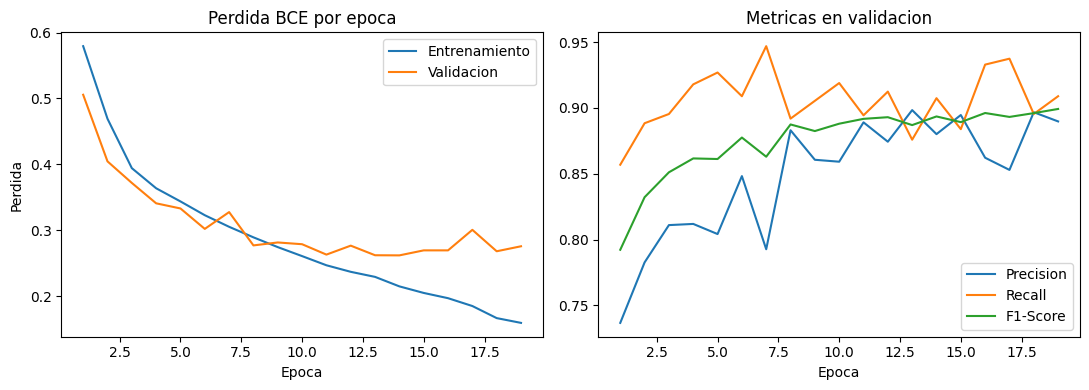

Figura guardada en /home/jaime/Projects/maia/local/tdl/miniproyecto2/paper_template/curvas_entrenamiento.png


In [29]:
# Curvas de entrenamiento

def graficar_historial(historial: dict[str, list[float]]) -> None:
    # type: (dict[str, list[float]]) -> None
    """Genera y guarda curvas de perdida y metricas de validacion."""
    epocas: list[int] = list(range(1, len(historial['train_loss']) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epocas, historial['train_loss'], label='Entrenamiento')
    axes[0].plot(epocas, historial['val_loss'],   label='Validacion')
    axes[0].set_title('Perdida BCE por epoca')
    axes[0].set_xlabel('Epoca')
    axes[0].set_ylabel('Perdida')
    axes[0].legend()

    axes[1].plot(epocas, historial['val_precision'], label='Precision')
    axes[1].plot(epocas, historial['val_recall'],    label='Recall')
    axes[1].plot(epocas, historial['val_f1'],        label='F1-Score')
    axes[1].set_title('Metricas en validacion')
    axes[1].set_xlabel('Epoca')
    axes[1].legend()

    plt.tight_layout()
    ruta: Path = PAPER_DIR / 'curvas_entrenamiento.png'
    plt.savefig(ruta, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada en {ruta}')


graficar_historial(historial)

## 7. Resultado cuantitativo

La evaluación sobre el conjunto de prueba (4000 reseñas nunca vistas durante el entrenamiento) arroja:

| Métrica | Valor |
|---|---|
| Precisión | 0.8766 |
| Recall | 0.9104 |
| F1-Score | **0.8932** |

El modelo clasifica correctamente el 89 % de las reseñas, con un Recall superior a la Precisión, lo que indica que el modelo minimiza los falsos negativos (reseñas positivas clasificadas como negativas) a costa de aceptar algunos falsos positivos. Este comportamiento es consistente con lo observado en validación y sugiere que el umbral de decisión (0.5) podría ajustarse según la aplicación.

In [30]:
# Evaluacion final en conjunto de prueba
modelo.eval()
preds_test:  list[int] = []
labels_test: list[int] = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = modelo(X_batch)
        preds_test.extend((pred >= 0.5).long().cpu().numpy())
        labels_test.extend(y_batch.long().numpy())

precision: float = precision_score(labels_test, preds_test, zero_division=0)
recall:    float = recall_score(labels_test,    preds_test, zero_division=0)
f1:        float = f1_score(labels_test,        preds_test, zero_division=0)

print('Resultados en conjunto de prueba:')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')

resultados: dict[str, float] = {'precision': precision, 'recall': recall, 'f1': f1}
with open(PAPER_DIR / 'resultados.json', 'w') as fh:
    json.dump(resultados, fh, indent=2)
print(f'Resultados guardados en {PAPER_DIR / "resultados.json"}')

Resultados en conjunto de prueba:
  Precision: 0.8766
  Recall:    0.9104
  F1-Score:  0.8932
Resultados guardados en /home/jaime/Projects/maia/local/tdl/miniproyecto2/paper_template/resultados.json


## 8. Análisis cualitativo

**El aprendizaje por transferencia funciona, incluso con vocabulario parcial.** Con una cobertura GloVe del 77 %, el modelo alcanza un F1 de 0.89, lo que indica que los vectores preentrenados aportan representación suficientemente sin necesidad de entrenar embeddings desde cero.

**La estrategia congelar/descongelar acelera la convergencia.** Las métricas de validación mejoran visiblemente en las primeras 6 épocas (cuando los embeddings están fijos y la BiLSTM aprende patrones secuenciales), y luego se estabilizan con el ajuste fino. Esto evita que el ruido de los gradientes del LSTM distorsionen los embeddings al inicio.

**El modelo tiene un sesgo hacia la clase positiva.** En validación y prueba el Recall supera sistemáticamente a la Precisión (~0.91 vs ~0.88), lo que indica que el modelo prefiere clasificar como positivo ante ambigüedad. Esto puede deberse al lenguaje intenso o lleno de exclamaciones, que se presenta en las reseñas. Esto los los vectores GloVe lo asocian con positividad.

**La arquitectura es adecuada pero con margen de mejora.** La brecha creciente entre pérdida de entrenamiento y validación en las épocas finales sugiere que el modelo (7.6 M parámetros) tiene capacidad suficiente para sobreajustar; variantes como aumentar dropout, reducir `hidden_dim` o agregar una segunda capa recurrente podrían mejorar la generalización.
